# Visión por computador: Ejercicio práctico clase 02
## Grupo 01:

### Integrantes:

- Jhon Oña
- Ivan Ortega
- Brandon Vega

#### Repositorio de Codigo 

[Github Repo](https://github.com/jeonag/vision-por-computador/tree/main/ejercicion_clase2)

## Ejercicio 

### Actividad individual calificable:

En esta actividad, llevaremos a cabo una serie de pruebas para evaluar la capacidad de nuestro modelo de clasificación de imágenes sobre una base de datos que debe ser creada por cada estudiante/grupo. El objetivo es identificar correctamente si una imagen contiene el rostro de un estudiante específico o si pertenece a un fondo. Para ello, hemos definido dos etiquetas principales:

##### **Label 1:** `Nombre del estudiante`
##### **Label 2:** `Fondo` (imagenes que no contengan el rostro del estudiante)

#### **Pruebas:**

Las pruebas se realizarán con diferentes tipos de imágenes de entrada para verificar la precisión del modelo en escenarios no vistos durante el entrenamiento:

1. **Input image:** Foto del estudiante que no se encuentre en la carpeta de entrenamiento (tómate una foto el día de la presentación usando tu webcam).
**Required output label:** `Nombre del estudiante`

2. **Input image:** Fondo que no se encuentre en la carpeta de entrenamiento (el estudiante que presente antes de ti te dará la palabra de búsqueda, puedes descargarla de Google Images).
**Required output label:** `Fondo`
3. **Input image:** Foto de un rostro diferente al rostro del estudiante que no se encuentre en las carpetas de entrenamiento (el estudiante que presente antes de ti te dará un nombre de una celebridad que se parezca a ti, puedes descargarla de Google Images).
**Required output label:** `Fondo`

## Entrenamiento del modelo

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping



Función para cargar las imagenes para el entrenamiento y se ha seleccionado desde una carpeta llamada **ivan**

Las etiquetas se asignara 1 para **ivan** y 0 para **fondo**

In [3]:
def load_images(folder):
    # Inicializamos las listas para almacenar las imágenes y las etiquetas
    images = []
    labels = []

    # Obtener el nombre de la carpeta
    folder_name = os.path.basename(folder)

    # Iteramos sobre cada archivo en la carpeta especificada
    for filename in os.listdir(folder):
        # Leemos la imagen utilizando OpenCV
        img = cv2.imread(os.path.join(folder, filename))

        # Si la imagen se ha leído correctamente
        if img is not None:
            # Redimensionamos la imagen a 224x224 píxeles para que coincida con la dimensión de entrada de VGG-16
            img = cv2.resize(img, (224, 224))
            # Añadimos la imagen a la lista de imágenes
            images.append(img)

            # Asignamos la etiqueta correspondiente según la carpeta
            if folder_name == 'ivan':
                labels.append(1) # Etiqueta 1 para ivan
            elif folder_name == 'fondo':
                labels.append(0) # Etiqueta 0 para fondo

    return images, labels

# Cargamos las imágenes y etiquetas de ivan desde el directorio especificado
# La función load_images se encarga de leer las imágenes y sus etiquetas correspondientes
ivan_images, ivan_labels = load_images('./ivan')

# Cargamos las imágenes y etiquetas de fondo desde el directorio especificado
# Similar a la carga de imágenes de ivan, esta función lee las imágenes de fondo y sus etiquetas
fondo_images, fondo_labels = load_images('./fondo')

# Combinamos los arrays de ivan y fondo para crear un conjunto de datos completo
images = np.array(ivan_images + fondo_images)
labels = np.array(ivan_labels + fondo_labels)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [4]:
from keras.utils import to_categorical

# One-hot encoding de las etiquetas
labels = to_categorical(labels) # Convertimos las etiquetas a formato one-hot encoding. Las etiquetas originales eran 0 y 1, y ahora se convierten en vectores binarios.
labels

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.

Se separa el data set en training y test, manteniendo 20% del data set para pruebas

In [5]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2)

In [6]:
# Definimos el callback de EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Cargamos la red VGG16, asegurándonos de que se dejan fuera las capas superiores de la red preentrenada (head FC layer)
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Construimos la capa que se colocará en la parte superior del modelo base (baseModel)
model = Sequential()
model.add(baseModel)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Agregamos una capa de Dropout con una tasa de 0.5
model.add(Dense(2, activation='softmax'))  # Dos clases (perro y gato), por lo que la capa de salida tiene 2 neuronas

# Congelamos las capas del modelo base para que no se actualicen durante el entrenamiento
for layer in baseModel.layers:
    layer.trainable = False

# Compilamos el modelo 
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenamos el modelo
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=300, batch_size=32, callbacks=[early_stopping])

# Evaluamos el modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

Epoch 1/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.8920 - loss: 5.3440 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.9972 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/300
12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 

In [7]:
# Exportamos en modelo en un formato .h5
model.save('modelo_practica.h5')

### Evaluacion de Resultados

1. **Input image:** Foto del estudiante que no se encuentre en la carpeta de entrenamiento (tómate una foto el día de la presentación usando tu webcam).
**Required output label:** `Nombre del estudiante`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


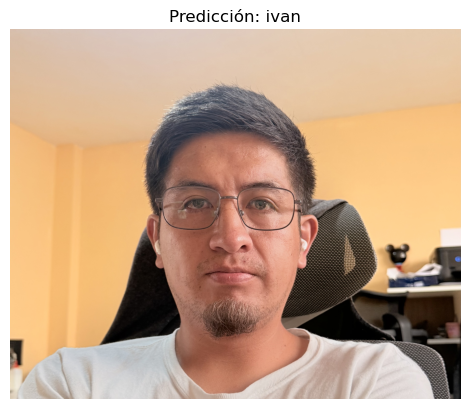

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


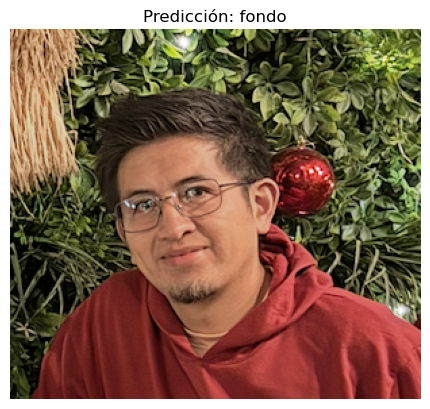

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


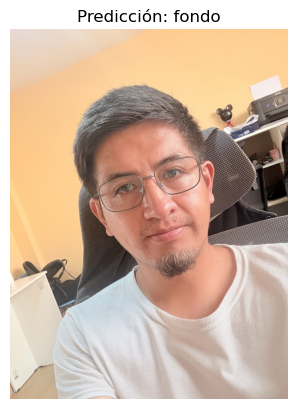

In [28]:
from keras.models import load_model

import matplotlib.pyplot as plt

import cv2


model = load_model('modelo_practica.h5')

def predict_image(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224, 224))

    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)


    plt.imshow(img_rgb)
    plt.title(f'Predicción: {"ivan" if np.argmax(pred) == 1 else "fondo"}')
    plt.axis('off')
    plt.show()

# Realizamos la predicción utilizando el modelo cargado
predict_image('testing/ivan_testing.jpg')
predict_image('testing/ivan_testing_old.png')
predict_image('testing/ivan_testing_camera.jpg')


2. **Input image:** Fondo que no se encuentre en la carpeta de entrenamiento (el estudiante que presente antes de ti te dará la palabra de búsqueda, puedes descargarla de Google Images).
**Required output label:** `Fondo`


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


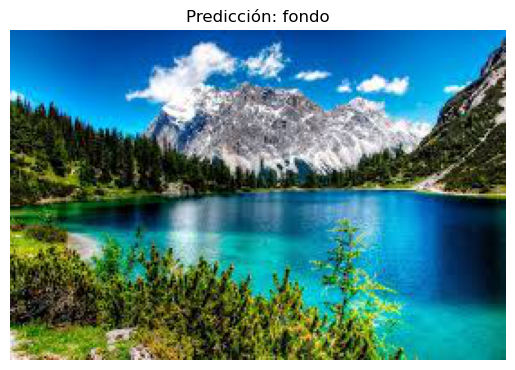

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


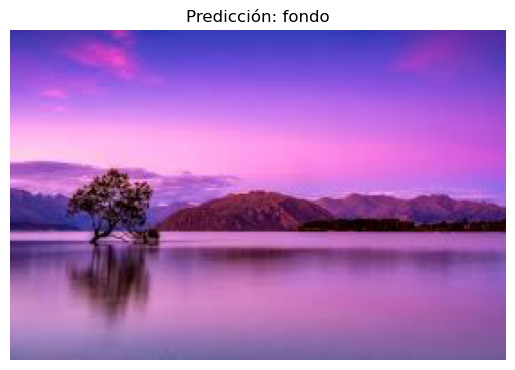

In [13]:
predict_image('testing/paisaje.jpeg')
predict_image('testing/paisaje_2.jpeg')

3. **Input image:** Foto de un rostro diferente al rostro del estudiante que no se encuentre en las carpetas de entrenamiento (el estudiante que presente antes de ti te dará un nombre de una celebridad que se parezca a ti, puedes descargarla de Google Images).
**Required output label:** `Fondo`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


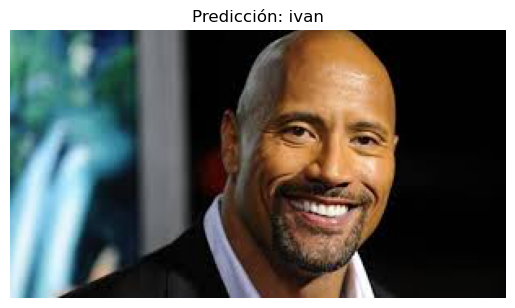

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


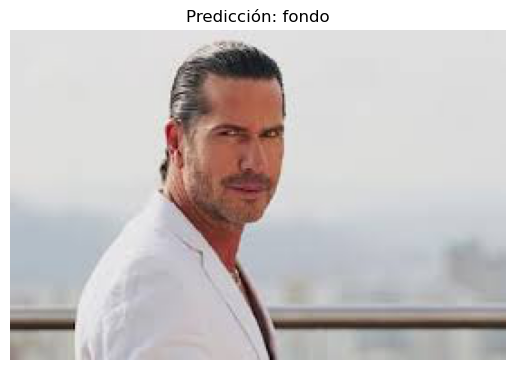

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


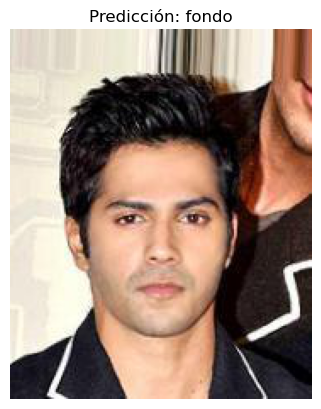

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


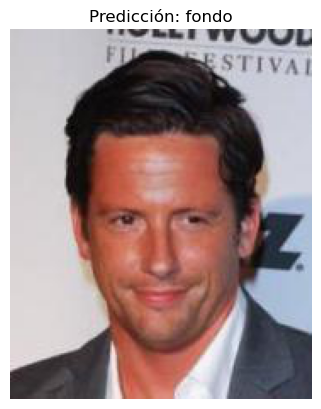

In [16]:
predict_image('testing/famoso_2.jpeg')
predict_image('testing/famoso_3.jpeg')
predict_image('testing/famoso_4.jpg')
predict_image('testing/famoso_5.jpg')

### Conclusiones

- **Resultados del entrenamiento**: Tras entrenar el modelo con las imágenes de "Iván" y "fondo", se logró mantener una buena precisión en la clasificación de las imágenes de prueba. El modelo fue capaz de identificar correctamente ambas categorías en la mayoría de los casos; sin embargo, existen falsos positivos y negativos que podrían deberse a la falta de variedad y cantidad de imágenes en el conjunto de datos de entrenamiento.
- **Detección de fondo**: El modelo es bastante eficiente al detectar paisajes o fondos (backgrounds). Esto puede atribuirse a que en la categoría de "fondo" se incluyeron diversos tipos de paisajes ademas de rostros de otras personas. Por lo tanto, el nivel de exactitud es notablemente alto al procesar este tipo de imágenes.
- **Detección del estudiante**: En cuanto a la identificación del estudiante, se evidenció un nivel de exactitud elevado en imágenes con posiciones e iluminación similares a las de entrenamiento. Al contrario al utilizar fotografías con diferentes tonos de luz y ángulos, el modelo falló en la predicción. Esto puede llevar a la conclusión de el tamaño y la diversidad del dataset no fueron suficientes para generalizar el reconocimiento en condiciones variables.
- **Deteccion de otros rostros**: Del mismo modo, existen casos en los que el modelo genera falsos positivos con fotografías de personas famosas, aunque la mayor parte del tiempo sus predicciones son acertadas. Este comportamiento puede estar dado ya que durante el entrenamiento se inserto un de fotos de varias celebridades, lo que puede haber permitido al modelo mejorar su capacidad predictiva en estos casos específicos.